In [2]:
# Fig 4A picture drawing
"""
Functions:
1. Read stranded occupations file: strandind_new_ocu.dta
2. Read OEWS 2023 data: oes_research_2023_allsectors.xlsx
3. Match stranded occupations using Occupationcode / OCC_CODE
4. Define stranded industries using 4-digit NAICS
5. Calculate for each state:
   (1) Employment in stranded occupations within stranded industries
   (2) Employment in non-stranded industries
   (3) Ratio between the two
6. Plot US state-level choropleth map
7. Export results to CSV / HTML / PDF
"""

import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

# =========================
# 1. File Paths
# =========================
occ_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/strandind_new_ocu.dta")
oes_path = Path("Your path/Stranded_Occupations_Replication/Data/raw_new/oes_wage/oes_research_2023_allsectors.xlsx")

out_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/Fig 4A.csv")
out_html = Path("Your path/Stranded_Occupations_Replication/Data/temp/Fig 4A.html")
out_pdf = Path("Your path/Stranded_Occupations_Replication/Data/temp/Fig 4A.pdf")

# =========================
# 2. Stranded Industry Definition (4-digit NAICS)
# =========================
stranded_naics4 = {
    "2111", "2121", "2131", "2211", "2212", "2371",
    "3241", "3251", "3331", "3363", "4235", "4247",
    "4571", "4572", "4861", "4862", "4869"
}

# =========================
# 3. State Name -> Abbreviation Mapping
# =========================
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY"
}

# =========================
# 4. Read Stranded Occupations File
# =========================
occ = pd.read_stata(occ_path)
occ.columns = [c.strip() for c in occ.columns]

if "Occupationcode" not in occ.columns:
    raise ValueError("Column 'Occupationcode' not found in strandind_new_ocu.dta")

occ["Occupationcode"] = occ["Occupationcode"].astype(str).str.strip()
stranded_occ = set(occ["Occupationcode"].dropna().unique())

print("Number of stranded occupations:", len(stranded_occ))
print("Sample stranded occupations:", list(sorted(stranded_occ))[:10])

# =========================
# 5. Read OEWS Data
# =========================
df = pd.read_excel(oes_path, dtype=str)
df.columns = [c.strip() for c in df.columns]

for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

# =========================
# 6. Check Required Columns
# =========================
required_cols = ["AREA_TITLE", "NAICS", "OCC_CODE", "TOT_EMP"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in oes_research_2023_allsectors.xlsx: {missing_cols}")

# =========================
# 7. Clean Employment Values
# =========================
df["TOT_EMP"] = (
    df["TOT_EMP"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("*", "", regex=False)
    .str.replace("#", "", regex=False)
    .str.strip()
)
df["TOT_EMP"] = pd.to_numeric(df["TOT_EMP"], errors="coerce")

# =========================
# 8. Clean Industry Codes
#    Extract digits only, then take first 4 characters
# =========================
df["NAICS"] = df["NAICS"].astype(str).str.strip()
df["NAICS_num"] = df["NAICS"].str.extract(r"(\d+)", expand=False)
df["NAICS4"] = df["NAICS_num"].str[:4]

# =========================
# 9. Clean Occupation Codes
# =========================
df["OCC_CODE"] = df["OCC_CODE"].astype(str).str.strip()

# =========================
# 10. Map State Abbreviations
# =========================
df["AREA_TITLE"] = df["AREA_TITLE"].astype(str).str.strip()
df["state_abbrev"] = df["AREA_TITLE"].map(state_abbrev)

# Print unmatched areas for debugging
unmatched = sorted(df.loc[df["state_abbrev"].isna(), "AREA_TITLE"].dropna().unique().tolist())
if unmatched:
    print("\nThe following AREA_TITLE values are not standard state names and will be excluded (first 50):")
    print(unmatched[:50])

# Keep only state-level records
df = df[df["state_abbrev"].notna()].copy()

print("\nValid records for state map:", len(df))
print("Number of states:", df["state_abbrev"].nunique())

# =========================
# 11. Numerator:
#     State-level employment in stranded occupations WITHIN stranded industries
# =========================
num_df = df[
    df["NAICS4"].isin(stranded_naics4) &
    df["OCC_CODE"].isin(stranded_occ)
].copy()

state_num = (
    num_df.groupby(["AREA_TITLE", "state_abbrev"], as_index=False)["TOT_EMP"]
          .sum(min_count=1)
          .rename(columns={
              "AREA_TITLE": "state_name",
              "TOT_EMP": "stranded_occ_in_stranded_ind_emp"
          })
)

# =========================
# 12. Denominator:
#     State-level employment in NON-stranded industries
# =========================
den_df = df[~df["NAICS4"].isin(stranded_naics4)].copy()

state_den = (
    den_df.groupby(["AREA_TITLE", "state_abbrev"], as_index=False)["TOT_EMP"]
          .sum(min_count=1)
          .rename(columns={
              "AREA_TITLE": "state_name",
              "TOT_EMP": "non_stranded_ind_emp"
          })
)

# =========================
# 13. Merge and Calculate Ratio
# =========================
state_ratio = pd.merge(
    state_den,
    state_num[["state_abbrev", "stranded_occ_in_stranded_ind_emp"]],
    on="state_abbrev",
    how="left"
)

# Use state names from denominator table
state_ratio["stranded_occ_in_stranded_ind_emp"] = state_ratio["stranded_occ_in_stranded_ind_emp"].fillna(0)

state_ratio["ratio"] = np.where(
    state_ratio["non_stranded_ind_emp"] > 0,
    state_ratio["stranded_occ_in_stranded_ind_emp"] / state_ratio["non_stranded_ind_emp"],
    np.nan
)

# Convert to percentage for readability
state_ratio["ratio_pct"] = state_ratio["ratio"] * 100

# Sort by ratio descending
state_ratio = state_ratio.sort_values("ratio", ascending=False).reset_index(drop=True)

# =========================
# 14. Export Results
# =========================
state_ratio.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"\nResults saved to: {out_csv}")

# =========================
# 15. Plot Choropleth Map
# =========================
fig = px.choropleth(
    state_ratio,
    locations="state_abbrev",
    locationmode="USA-states",
    color="ratio",
    scope="usa",
    hover_name="state_name",
    hover_data={
        "state_abbrev": False,
        "stranded_occ_in_stranded_ind_emp": ":,.0f",
        "non_stranded_ind_emp": ":,.0f",
        "ratio": ":.4f",
        "ratio_pct": ":.2f"
    },
    color_continuous_scale="Purples",
    title="Ratio of employment in stranded industries to non-stranded industry, 2023"
)

# =========================
# 16. Layout Formatting
# =========================
fig.update_layout(
    width=1500,
    height=950,
    title=dict(
        text="Ratio of employment in stranded industries to non-stranded industry, 2023",
        x=0.5,
        xanchor="center",
        font=dict(size=24)
    ),
    font=dict(size=18),
    margin=dict(l=30, r=30, t=100, b=30),
    coloraxis_colorbar=dict(
        title=dict(
            text="Ratio",
            font=dict(size=22)
        ),
        tickfont=dict(size=18),
        len=0.8,
        thickness=28
    )
)

fig.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Stranded occupations in stranded industries: %{customdata[0]:,.0f}<br>"
        "Non-stranded industry employment: %{customdata[1]:,.0f}<br>"
        "Ratio: %{z:.4f}<br>"
        "Ratio (%): %{customdata[3]:.2f}%"
        "<extra></extra>"
    ),
    hoverlabel=dict(font_size=18)
)

# =========================
# 17. Export HTML
# =========================
fig.write_html(str(out_html))
print(f"Map HTML saved to: {out_html}")

# =========================
# 18. Export PDF
#     Requires kaleido:
#     pip install -U kaleido
# =========================
try:
    fig.write_image(str(out_pdf), format="pdf", width=1500, height=950, scale=2)
    print(f"Map PDF saved to: {out_pdf}")
except Exception as e:
    print("\nPDF export failed – usually because kaleido is not installed.")
    print("Please run: pip install -U kaleido")
    print("Error message:", e)

# =========================
# 19. Print Top 10 States
# =========================
print("\nTop 10 states by ratio:")
print(
    state_ratio[
        ["state_name", "stranded_occ_in_stranded_ind_emp", "non_stranded_ind_emp", "ratio", "ratio_pct"]
    ].head(10)
)

搁浅职业数量: 399
搁浅职业示例: ['11-1011', '11-1021', '11-2011', '11-2021', '11-2022', '11-2032', '11-3012', '11-3013', '11-3021', '11-3031']

以下 AREA_TITLE 不是标准州名，已自动排除（前50个）:
['Guam', 'Puerto Rico', 'Virgin Islands']

可用于州地图的记录数: 281960
州数量: 51

结果表已保存: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Fig 4A.csv
地图 HTML 已保存: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Fig 4A.html
地图 PDF 已保存: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Fig 4A.pdf

比值最高的前10个州:
      state_name  stranded_occ_in_stranded_ind_emp  non_stranded_ind_emp  \
0        Wyoming                           19940.0              191870.0   
1   North Dakota                           22500.0              314830.0   
2  West Virginia                           33900.0              540700.0   
3     New Mexico                           34960.0              667590.0   
4      Louisiana                    

In [5]:
# Fig 4B & Supplementary Figure 5C-F data process
"""
Read the 'line_item' sheet from ep_industry_name.xlsx
Keep only industries mentioned in the line_item sheet
Classify these industries into: stranded industries vs non-stranded industries, based on 'strandind' flag
Read the corresponding forecast CSV files for these industries from the bls_matrix folder
Sum the 'Employment Change, 2024-2034' values in each industry file
Export separately:
Aggregated employment change by occupation for NON-stranded industries
Aggregated employment change by occupation for STRANDED industries
"""

import os
import re
import glob
import pandas as pd
from pathlib import Path

# =========================================================
# 1. Path Configuration
# =========================================================
base_dir = Path("Your path/Stranded_Occupations_Replication/Data/raw_new/bls_matrix")
temp_dir = Path("Your path/Stranded_Occupations_Replication/Data/temp")

excel_path = base_dir / "ep_industry_name.xlsx"

# Output files
out_non_strand = temp_dir / "non_strandind_occupation_employment_change_2024_2034.csv"
out_strand = temp_dir / "strandind_occupation_employment_change_2024_2034.csv"
out_detail = temp_dir / "industry_occupation_employment_change_detail.csv"

# =========================================================
# 2. Read 'line_item' sheet from Excel
# =========================================================
df_line = pd.read_excel(excel_path, sheet_name="Line item", dtype=str)
df_line.columns = [str(c).strip() for c in df_line.columns]

print("line_item sheet columns:")
print(df_line.columns.tolist())

# =========================================================
# 3. Auto-detect industry code column and strandind column
# =========================================================
code_col = None
strand_col = None

for c in df_line.columns:
    c_lower = c.lower()
    if "2024 national employment matrix code" in c_lower:
        code_col = c
    if "strandind" in c_lower:
        strand_col = c

if code_col is None:
    raise ValueError("Industry code column not found. Please check for '2024 National Employment Matrix code' in line_item sheet")
if strand_col is None:
    raise ValueError("strandind column not found in line_item sheet")

df_line = df_line[[code_col, strand_col]].copy()
df_line[code_col] = df_line[code_col].astype(str).str.strip()
df_line[strand_col] = df_line[strand_col].astype(str).str.strip()

df_line = df_line[df_line[code_col] != ""]
df_line = df_line[df_line[code_col].str.lower() != "nan"]
df_line = df_line.drop_duplicates(subset=[code_col])

# =========================================================
# 4. Standardize strandind flag
# =========================================================
def normalize_strandind(x):
    if pd.isna(x):
        return 0
    s = str(x).strip().lower()
    if s in {"1", "yes", "y", "true", "strandind", "stranded"}:
        return 1
    if s in {"0", "no", "n", "false", ""}:
        return 0
    return 0

df_line["strandind_flag"] = df_line[strand_col].apply(normalize_strandind)

# Industry code -> strandind_flag mapping
industry_map = dict(zip(df_line[code_col], df_line["strandind_flag"]))

print(f"\nNumber of industries in line_item: {len(industry_map)}")
print(f"Number of stranded industries: {sum(industry_map.values())}")
print(f"Number of non-stranded industries: {len(industry_map) - sum(industry_map.values())}")

# =========================================================
# 5. Find all CSV files
# =========================================================
csv_files = glob.glob(os.path.join(base_dir, "*.csv"))
print(f"\nNumber of CSV files found: {len(csv_files)}")

# =========================================================
# 6. Extract industry code from filename
# =========================================================
def extract_industry_code_from_filename(filepath):
    filename = os.path.basename(filepath)
    m = re.match(r"^(\d+)", filename)
    if m:
        return m.group(1)
    return None

# =========================================================
# 7. Read matched industry CSV files
#    Columns to keep:
#    - Occupation Code
#    - Occupation Title
#    - Occupation Type
#    - Employment Change, 2024-2034
# =========================================================
all_rows = []

for fp in csv_files:
    industry_code = extract_industry_code_from_filename(fp)

    if industry_code is None:
        continue

    if industry_code not in industry_map:
        continue

    strand_flag = industry_map[industry_code]

    try:
        df = pd.read_csv(fp, dtype=str)
    except Exception as e:
        print(f"Failed to read: {os.path.basename(fp)}")
        print(f"Error message: {e}")
        continue

    # Clean column names
    df.columns = [str(c).strip() for c in df.columns]

    code_occ_col = "Occupation Code"
    title_col = "Occupation Title"
    type_col = "Occupation Type"
    change_col = "Employment Change, 2024-2034"

    missing_cols = [c for c in [code_occ_col, title_col, type_col, change_col] if c not in df.columns]
    if missing_cols:
        print(f"Missing columns {missing_cols}, skipped: {os.path.basename(fp)}")
        continue

    tmp = df[[code_occ_col, title_col, type_col, change_col]].copy()

    # Clean string columns
    for c in [code_occ_col, title_col, type_col]:
        tmp[c] = tmp[c].astype(str).str.strip()

    # Convert employment change to numeric
    tmp[change_col] = (
        tmp[change_col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    tmp[change_col] = pd.to_numeric(tmp[change_col], errors="coerce")

    # Remove rows with empty occupation fields
    tmp = tmp[tmp[code_occ_col] != ""]
    tmp = tmp[tmp[code_occ_col].str.lower() != "nan"]
    tmp = tmp[tmp[title_col] != ""]
    tmp = tmp[tmp[title_col].str.lower() != "nan"]

    # Add industry and strandind information
    tmp["industry_code"] = industry_code
    tmp["strandind_flag"] = strand_flag

    all_rows.append(tmp)

if not all_rows:
    raise ValueError("No valid industry CSV data matched. Please check industry codes or CSV column names.")

df_all = pd.concat(all_rows, ignore_index=True)

# Save raw detailed data
df_all.to_csv(out_detail, index=False, encoding="utf-8-sig")

# =========================================================
# 8. Group and aggregate
#    Aggregate by Occupation Code + Occupation Title + Occupation Type
# =========================================================
group_cols = ["Occupation Code", "Occupation Title", "Occupation Type"]
change_col = "Employment Change, 2024-2034"

df_non_strand = (
    df_all[df_all["strandind_flag"] == 0]
    .groupby(group_cols, as_index=False)[change_col]
    .sum()
    .sort_values(change_col, ascending=False)
    .reset_index(drop=True)
)

df_strand = (
    df_all[df_all["strandind_flag"] == 1]
    .groupby(group_cols, as_index=False)[change_col]
    .sum()
    .sort_values(change_col, ascending=False)
    .reset_index(drop=True)
)

# Export results
df_non_strand.to_csv(out_non_strand, index=False, encoding="utf-8-sig")
df_strand.to_csv(out_strand, index=False, encoding="utf-8-sig")

# =========================================================
# 9. Print summary
# =========================================================
print("\n================ Result Summary ================")
print(f"Number of aggregated occupations in NON-stranded industries: {len(df_non_strand)}")
print(f"Number of aggregated occupations in STRANDED industries: {len(df_strand)}")

print("\nTop 10 occupations in NON-stranded industries:")
print(df_non_strand.head(10).to_string(index=False))

print("\nTop 10 occupations in STRANDED industries:")
print(df_strand.head(10).to_string(index=False))

print("\nFiles exported:")
print(f"1. Non-stranded industry occupation summary: {out_non_strand}")
print(f"2. Stranded industry occupation summary: {out_strand}")
print(f"3. Industry-occupation detailed data: {out_detail}")

line_item sheet columns:
['2024 National Employment Matrix title', '2024 National Employment Matrix code', 'Industry type', '2022 NAICS code', 'strandind']

line_item 中提到的行业数: 293
strandind 行业数: 17
非 strandind 行业数: 276

发现 CSV 文件数: 423

================ 结果概况 ================
非 strandind 行业中，汇总后的职业数: 1069
strandind 行业中，汇总后的职业数: 486

非 strandind 行业前10个职业：
Occupation Code                                                                              Occupation Title Occupation Type  Employment Change, 2024-2034
     ="00-0000"                                                                        Total, all occupations         Summary                        4313.0
     ="31-0000"                                                                Healthcare support occupations         Summary                         903.2
     ="31-1100" Home health and personal care aides; and nursing assistants, orderlies, and psychiatric aides         Summary                         746.8
     ="31-1120"     

In [6]:
#Fig 4B&Supplementary Figure 5C-F data process
"""
simocc_08.xlsx contains similar occupations with skill similarity >= 0.8 for occupations remaining in stranded industries, exported from Stata.
Match 'occupation_code' with 'Occupation Code' in strandind_occupation_employment_change_2024_2034.csv,
and merge the corresponding 'Employment Change, 2024-2034' values.
Match 'occupation_code_match' with 'Occupation Code' in non_strandind_occupation_employment_change_2024_2034.csv,
and merge the corresponding 'Employment Change, 2024-2034' values.
"""

import os
import pandas as pd
from pathlib import Path

# Base directories
base_dir = Path("Your path/Stranded_Occupations_Replication/Data/raw_new/bls_matrix")
temp_dir = Path("Your path/Stranded_Occupations_Replication/Data/temp")

# Input files
simocc_path = temp_dir / "simocc_08.xlsx"
strand_path = temp_dir / "strandind_occupation_employment_change_2024_2034.csv"
non_strand_path = temp_dir / "non_strandind_occupation_employment_change_2024_2034.csv"

# Output files
out_xlsx = temp_dir / "simocc_08_with_employment_change.xlsx"
out_csv = temp_dir / "simocc_08_with_employment_change.csv"

# Read data
df_sim = pd.read_excel(simocc_path, dtype=str)
df_strand = pd.read_csv(strand_path, dtype=str)
df_non = pd.read_csv(non_strand_path, dtype=str)

# Clean column names
df_sim.columns = [str(c).strip() for c in df_sim.columns]
df_strand.columns = [str(c).strip() for c in df_strand.columns]
df_non.columns = [str(c).strip() for c in df_non.columns]

# Function to standardize occupation codes
def normalize_occ_code(x):
    if pd.isna(x):
        return None

    s = str(x).strip()

    # Handle Excel exported format: ="15-1252"
    if s.startswith('="') and s.endswith('"'):
        s = s[2:-1]

    # Remove quotes and equals sign
    s = s.replace('"', "").replace("'", "").replace("=", "")

    # Remove Excel .0 suffix
    if s.endswith(".0"):
        s = s[:-2]

    # Remove dashes, spaces, tabs
    s = s.replace("-", "").replace(" ", "").replace("\t", "")

    if s == "" or s.lower() == "nan":
        return None

    return s

# Standardize occupation codes
df_sim["occupation_code_std"] = df_sim["occupation_code"].apply(normalize_occ_code)
df_sim["occupation_code_match_std"] = df_sim["occupation_code_match"].apply(normalize_occ_code)

df_strand["Occupation Code_std"] = df_strand["Occupation Code"].apply(normalize_occ_code)
df_non["Occupation Code_std"] = df_non["Occupation Code"].apply(normalize_occ_code)

# Check matching counts
sim_set = set(df_sim["occupation_code_std"].dropna().unique())
sim_match_set = set(df_sim["occupation_code_match_std"].dropna().unique())
strand_set = set(df_strand["Occupation Code_std"].dropna().unique())
non_set = set(df_non["Occupation Code_std"].dropna().unique())

print("Matches between occupation_code and stranded industries:", len(sim_set & strand_set))
print("Matches between occupation_code_match and non-stranded industries:", len(sim_match_set & non_set))

# Prepare matching dataframes
df_strand_match = df_strand[
    ["Occupation Code_std", "Occupation Code", "Occupation Title", "Occupation Type", "Employment Change, 2024-2034"]
].copy().drop_duplicates(subset=["Occupation Code_std"])

df_strand_match = df_strand_match.rename(columns={
    "Occupation Code": "strandind_Occupation Code",
    "Occupation Title": "strandind_Occupation Title",
    "Occupation Type": "strandind_Occupation Type",
    "Employment Change, 2024-2034": "employment_change_strandind"
})

df_non_match = df_non[
    ["Occupation Code_std", "Occupation Code", "Occupation Title", "Occupation Type", "Employment Change, 2024-2034"]
].copy().drop_duplicates(subset=["Occupation Code_std"])

df_non_match = df_non_match.rename(columns={
    "Occupation Code": "non_strandind_Occupation Code",
    "Occupation Title": "non_strandind_Occupation Title",
    "Occupation Type": "non_strandind_Occupation Type",
    "Employment Change, 2024-2034": "employment_change_non_strandind_match"
})

# First merge: occupation_code -> stranded industries
df_merged = df_sim.merge(
    df_strand_match,
    left_on="occupation_code_std",
    right_on="Occupation Code_std",
    how="left"
)
df_merged = df_merged.drop(columns=["Occupation Code_std"])

# Second merge: occupation_code_match -> non-stranded industries
df_merged = df_merged.merge(
    df_non_match,
    left_on="occupation_code_match_std",
    right_on="Occupation Code_std",
    how="left"
)
df_merged = df_merged.drop(columns=["Occupation Code_std"])

# Convert employment change to numeric
for col in [
    "employment_change_strandind",
    "employment_change_non_strandind_match"
]:
    df_merged[col] = (
        df_merged[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

# Export final result
df_merged.to_excel(out_xlsx, index=False)

# Print summary
print("\n================ Matching Results ================")
print("Total rows in simocc data:", len(df_merged))
print("Rows matched to stranded industries (occupation_code):",
      df_merged["employment_change_strandind"].notna().sum())
print("Rows matched to non-stranded industries (occupation_code_match):",
      df_merged["employment_change_non_strandind_match"].notna().sum())

print("\nOutput file saved to:")
print(out_xlsx)

occupation_code 与 strand 交集数量: 276
occupation_code_match 与 non_strand 交集数量: 679

================ 匹配结果 ================
simocc 总行数: 26424
occupation_code 匹配到 strandind 的行数: 20174
occupation_code_match 匹配到 non_strandind 的行数: 24835

输出文件：
/Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/simocc_08_with_employment_change.xlsx


In [7]:
#Fig 4B&Supplementary Figure 5C-F data process
"""
For each strandind_Occupation Title in simocc_08_with_employment_change.xlsx:

Keep employment_change_strandind_2024_2034 unchanged.
Sum up employment_change_non_strandind_match_2024_2034
for all its similar non_strandind_Occupation Title.

The final output table shows:
Total employment change of similar non-stranded industry occupations
for each stranded occupation (strandind occupation)
"""
import os
import re
import pandas as pd
import openpyxl
from pathlib import Path

# =========================================================
# 1. File Paths
# =========================================================
input_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/simocc_08_with_employment_change.xlsx")
out_path_excel = Path("Your path/Stranded_Occupations_Replication/Data/temp/strandind_to_nonstrandind_employment_change_summary.xlsx")

# =========================================================
# 2. Read Data
# =========================================================
df = pd.read_excel(input_path)
df.columns = [str(c).strip() for c in df.columns]

print("Column names:")
print(df.columns.tolist())

# =========================================================
# 3. Fix formula columns in ="11-1011" format (pandas reads as NaN)
# =========================================================
def extract_formula_string(val):
    """Extract string value from ="..." formula format"""
    if val is None:
        return None
    m = re.match(r'^="(.*)"$', str(val))
    return m.group(1) if m else str(val)

formula_cols = ["strandind_Occupation Code", "non_strandind_Occupation Code"]

wb = openpyxl.load_workbook(input_path)
ws = wb.active
headers = [ws.cell(1, c).value for c in range(1, ws.max_column + 1)]

for col_name in formula_cols:
    if col_name in headers:
        col_idx = headers.index(col_name) + 1
        values = [
            extract_formula_string(ws.cell(r, col_idx).value)
            for r in range(2, ws.max_row + 1)
        ]
        df[col_name] = values
        print(f"Fixed column: {col_name}, sample values: {values[:3]}")

wb.close()

# =========================================================
# 4. Check Required Columns
# =========================================================
required_cols = [
    "strandind_Occupation Code",
    "strandind_Occupation Title",
    "strandind_Occupation Type",
    "employment_change_strandind",
    "non_strandind_Occupation Code",
    "non_strandind_Occupation Title",
    "non_strandind_Occupation Type",
    "employment_change_non_strandind_match"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# =========================================================
# 5. Clean String Columns
# =========================================================
str_cols = [
    "strandind_Occupation Code",
    "strandind_Occupation Title",
    "strandind_Occupation Type",
    "non_strandind_Occupation Code",
    "non_strandind_Occupation Title",
    "non_strandind_Occupation Type"
]

for col in str_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# =========================================================
# 6. Debug Check
# =========================================================
print("\n================ Data Inspection ================")
print("Total rows:", len(df))

print("\nMissing ratio in grouping columns:")
print(df[str_cols[:3]].isna().mean())

print("\nUnique values in grouping columns:")
for col in str_cols[:3]:
    print(col, df[col].nunique(dropna=True))

# =========================================================
# 7. Aggregate by Stranded Occupation
# =========================================================
group_cols = [
    "strandind_Occupation Code",
    "strandind_Occupation Title",
    "strandind_Occupation Type"
]

summary = (
    df.groupby(group_cols, as_index=False, dropna=False)
      .agg(
          employment_change_strandind_2024_2034=("employment_change_strandind", "first"),
          total_employment_change_non_strandind_match_2024_2034=("employment_change_non_strandind_match", "sum"),
          matched_non_strandind_count=("non_strandind_Occupation Code", lambda x: x.notna().sum()),
          matched_non_strandind_unique_count=("non_strandind_Occupation Code", lambda x: x.dropna().nunique())
      )
)

# =========================================================
# 8. Calculate Net Change Gap
# =========================================================
summary["net_change_gap"] = (
    summary["total_employment_change_non_strandind_match_2024_2034"]
    - summary["employment_change_strandind_2024_2034"]
)

# =========================================================
# 9. Sort Results
# =========================================================
# Remove rows with empty stranded occupation code (empty groups from non-stranded occupations)
summary = summary[summary["strandind_Occupation Code"].notna()].reset_index(drop=True)

summary = summary.sort_values(
    by="total_employment_change_non_strandind_match_2024_2034",
    ascending=False
).reset_index(drop=True)

# =========================================================
# 10. Export Results
# =========================================================
summary.to_excel(out_path_excel, index=False)

# =========================================================
# 11. Print Summary
# =========================================================
print("\n================ Aggregation Complete ================")
print(f"Number of stranded occupations: {len(summary)}")

print("\nTop 10 results:")
print(summary.head(10).to_string(index=False))

print("\nOutput file:")
print(out_path_excel)

# =========================================================
# 12. Safety Checks
# =========================================================
assert len(summary) > 0, "❌ Result is empty, please check data!"
assert summary["strandind_Occupation Code"].notna().all(), "❌ Missing values in strandind_Occupation Code!"

列名如下：
['Occupationtitle', 'match_Occupationtitle', 'skill_similarity', 'occupation_code', 'type_skill_all', 'match_type_skill', 'occupation_code_match', 'strandind_new_ocu', 'nostrandind_new_ocu', 'occupation_code_std', 'occupation_code_match_std', 'strandind_Occupation Code', 'strandind_Occupation Title', 'strandind_Occupation Type', 'employment_change_strandind', 'non_strandind_Occupation Code', 'non_strandind_Occupation Title', 'non_strandind_Occupation Type', 'employment_change_non_strandind_match']
已修复列: strandind_Occupation Code，示例值: ['11-1011', '11-1011', '11-1011']
已修复列: non_strandind_Occupation Code，示例值: ['19-1032', '11-9111', '11-3111']

================ 数据检查 ================
总行数: 26424

分组列缺失比例：
strandind_Occupation Code     0.236527
strandind_Occupation Title    0.236527
strandind_Occupation Type     0.236527
dtype: float64

分组列唯一值数量：
strandind_Occupation Code 276
strandind_Occupation Title 276
strandind_Occupation Type 1

================ 汇总完成 ================
搁浅职业数量: 276


In [8]:
#Fig 4B&Supplementary Figure 5C-F picture drawing
"""
Functions:
1. Read employment change summary table
2. Read occupation_information
3. Standardize occupation code format to XX-XXXX
4. Match type_skill_all
5. Map to NRC / RC / NRM / RM categories
6. Plot overall chart and four horizontal lollipop charts
7. Negative values in red, positive values in default blue
8. Export SVG files
"""

import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. File Paths
# =========================
summary_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/strandind_to_nonstrandind_employment_change_summary.xlsx")
occinfo_path = Path("Your path/Stranded_Occupations_Replication/Data/raw/occupation_information.xlsx")
out_dir = Path("Your path/Stranded_Occupations_Replication/Data/temp")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 2. Function to standardize occupation code format
#    Target format: 11-9161
# =========================
def to_soc_code(val):
    """
    Convert various formats to XX-XXXX, e.g.:
    119161      -> 11-9161
    119161.0    -> 11-9161
    11-9161     -> 11-9161
    11 9161     -> 11-9161
    """
    if pd.isna(val):
        return pd.NA

    s = str(val).strip()

    # Case 1: 6 digits only, or 6 digits with decimal
    m = re.match(r"^\s*(\d{6})(?:\.\d+)?\s*$", s)
    if m:
        digits = m.group(1)
        return f"{digits[:2]}-{digits[2:]}"

    # Case 2: Remove all non-digit characters and process
    digits = re.sub(r"\D", "", s)
    if len(digits) < 6:
        return pd.NA

    digits = digits[:6]
    return f"{digits[:2]}-{digits[2:]}"

# =========================
# 3. Read Data
# =========================
summary_df = pd.read_excel(summary_path)
occ_df = pd.read_excel(occinfo_path)

# =========================
# 4. Standardize Code Formats
# =========================
summary_df["code_std"] = summary_df["strandind_Occupation Code"].apply(to_soc_code)
occ_df["code_std"] = occ_df["occupation_code"].apply(to_soc_code)

# Convert net_change_gap to numeric
summary_df["net_change_gap"] = pd.to_numeric(summary_df["net_change_gap"], errors="coerce")

# =========================
# 5. Map type_skill_all to four category abbreviations
# =========================
type_map = {
    "Non-Routine Cognitive": "NRC",
    "Routine Cognitive": "RC",
    "Non-Routine Manual": "NRM",
    "Routine Manual": "RM",
}

occ_df["type_skill_group"] = occ_df["type_skill_all"].map(type_map)

# Keep only columns needed for matching
occ_use = occ_df[["code_std", "type_skill_all", "type_skill_group"]].drop_duplicates().copy()

# =========================
# 6. Merge Data
# =========================
merged = summary_df.merge(occ_use, on="code_std", how="left")

# Remove duplicates if code_std appears multiple times in occ_use
merged = merged.drop_duplicates(
    subset=["strandind_Occupation Code", "net_change_gap", "type_skill_group"]
).copy()

# Export matched table
merged.to_excel(out_dir / "strandind_to_nonstrandind_employment_change_summary_matched_type_skill.xlsx", index=False)

# Print matching results
print("===== Matching Results Check =====")
print("Total rows:", len(merged))
print("Non-missing type_skill_group count:", merged["type_skill_group"].notna().sum())
print("\nCount by category:")
print(merged["type_skill_group"].value_counts(dropna=False))

# =========================
# 7. Plotting Function
# =========================
def draw_lollipop(data, title, output_svg, xlim=None):
    """
    Horizontal lollipop chart:
    - Negative values: red
    - Positive values: default blue
    - 0 as central axis
    - Hide y-axis tick labels
    """
    plot_df = (
        data.dropna(subset=["net_change_gap"])
            .copy()
            .sort_values("net_change_gap", ascending=True)
            .reset_index(drop=True)
    )

    if plot_df.empty:
        print(f"Skip empty plot: {title}")
        return

    fig, ax = plt.subplots(figsize=(16, 8))

    neg_mask = plot_df["net_change_gap"] < 0
    pos_mask = ~neg_mask

    # Negative values: red lines + red dots
    ax.hlines(
        y=plot_df.index[neg_mask],
        xmin=0,
        xmax=plot_df.loc[neg_mask, "net_change_gap"],
        linewidth=0.9,
        color="red"
    )
    ax.scatter(
        plot_df.loc[neg_mask, "net_change_gap"],
        plot_df.index[neg_mask],
        s=16,
        color="red"
    )

    # Positive values: default blue lines + dots
    ax.hlines(
        y=plot_df.index[pos_mask],
        xmin=0,
        xmax=plot_df.loc[pos_mask, "net_change_gap"],
        linewidth=0.9
    )
    ax.scatter(
        plot_df.loc[pos_mask, "net_change_gap"],
        plot_df.index[pos_mask],
        s=16
    )

    # 0 central axis
    ax.axvline(0, linewidth=1.2, linestyle="--")

    # Hide y-axis tick labels
    ax.set_yticks([])
    ax.set_ylabel("")

    # Set x-axis range (unify scale for all 5 plots if xlim is provided)
    if xlim is not None:
        ax.set_xlim(xlim)

    ax.set_xlabel("net_change_gap", fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    # Styling
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    plt.tight_layout()
    fig.savefig(output_svg, format="svg", bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {output_svg}")

# =========================
# 8. Unify x-axis range (recommended)
# =========================
plot_base = merged.dropna(subset=["net_change_gap"]).copy()
xmin = plot_base["net_change_gap"].min()
xmax = plot_base["net_change_gap"].max()

# Add small padding
padding = (xmax - xmin) * 0.03
xlim = (xmin - padding, xmax + padding)

# =========================
# 9. Plot overall chart
# =========================
draw_lollipop(
    data=merged,
    title="net_change_gap",
    output_svg=out_dir / "net_change_gap_lollipop_all_neg_red_matched.svg",
    xlim=xlim
)

# =========================
# 10. Plot separately by NRC / RC / NRM / RM
# =========================
for g in ["NRC", "RC", "NRM", "RM"]:
    sub = merged[merged["type_skill_group"] == g].copy()

    draw_lollipop(
        data=sub,
        title=f"net_change_gap - {g}",
        output_svg=out_dir / f"net_change_gap_lollipop_{g.lower()}_neg_red.svg",
        xlim=xlim
    )

print("\nAll tasks completed.")

===== 匹配结果检查 =====
总行数： 276
type_skill_group 非缺失数： 276

各类型数量：
type_skill_group
RM     137
NRC     88
RC      32
NRM     19
Name: count, dtype: int64
保存完成: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/net_change_gap_lollipop_all_neg_red_matched.svg
保存完成: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/net_change_gap_lollipop_nrc_neg_red.svg
保存完成: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/net_change_gap_lollipop_rc_neg_red.svg
保存完成: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/net_change_gap_lollipop_nrm_neg_red.svg
保存完成: /Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/net_change_gap_lollipop_rm_neg_red.svg

全部完成。


In [9]:
#Supplementary Figure 5A picture drawing
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

# =========================
# 1. File Paths
# =========================
occ_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/strandind_new_ocu.dta")
occ_match_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/occupation_code_match_81.dta")
oes_path = Path("Your path/Stranded_Occupations_Replication/Data/raw_new/oes_wage/oes_research_2023_allsectors.xlsx")

out_csv  = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 5A.csv")
out_html = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 5A.html")
out_svg  = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 5A.svg")
out_pdf  = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 5A.pdf")

# =========================
# 2. Stranded Industries (4-digit NAICS)
# =========================
stranded_naics4 = {
    "2111", "2121", "2131", "2211", "2212", "2371",
    "3241", "3251", "3331", "3363", "4235", "4247",
    "4571", "4572", "4861", "4862", "4869"
}

# =========================
# 3. State Name Mapping
# =========================
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY"
}

# =========================
# 4. Stranded Occupations
# =========================
occ = pd.read_stata(occ_path)
occ.columns = [c.strip() for c in occ.columns]
occ["Occupationcode"] = occ["Occupationcode"].astype(str).str.strip()
stranded_occ = set(occ["Occupationcode"].dropna().unique())

# =========================
# 5. Similar Occupations
# =========================
occ_match = pd.read_stata(occ_match_path)
occ_match.columns = [c.strip() for c in occ_match.columns]

occ_match["occ_code_clean"] = (
    occ_match["occupation_code_match"]
    .astype(float)
    .astype(int)
    .astype(str)
    .str.zfill(6)
)

occ_match["occ_code_oes"] = (
    occ_match["occ_code_clean"].str[:2] + "-" +
    occ_match["occ_code_clean"].str[2:]
)

similar_occ = set(occ_match["occ_code_oes"].dropna().unique())

# =========================
# 6. Load OEWS Data
# =========================
df = pd.read_excel(oes_path, dtype=str)
df.columns = [c.strip() for c in df.columns]
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

# =========================
# 7. Clean TOT_EMP
# =========================
df["TOT_EMP"] = (
    df["TOT_EMP"]
    .str.replace(",", "", regex=False)
    .str.replace("*", "", regex=False)
    .str.replace("#", "", regex=False)
)

df["TOT_EMP"] = pd.to_numeric(df["TOT_EMP"], errors="coerce")
df = df[df["TOT_EMP"].notna()].copy()

# =========================
# 8. Process NAICS Codes
# =========================
df["NAICS_num"] = df["NAICS"].str.extract(r"(\d+)", expand=False)
df["NAICS4"] = df["NAICS_num"].str[:4]

# =========================
# 9. Filter by State
# =========================
df["state_abbrev"] = df["AREA_TITLE"].map(state_abbrev)
df = df[df["state_abbrev"].notna()].copy()

# =========================
# 10. Calculate Numerator
# =========================
num_df = df[
    df["NAICS4"].isin(stranded_naics4) &
    df["OCC_CODE"].isin(stranded_occ)
].copy()

state_num = (
    num_df.groupby(["state_abbrev", "AREA_TITLE"], as_index=False)["TOT_EMP"]
          .sum()
          .rename(columns={"AREA_TITLE": "state_name", "TOT_EMP": "numerator_emp"})
)

# =========================
# 11. Calculate Denominator
# =========================
den_df = df[
    (~df["NAICS4"].isin(stranded_naics4)) &
    (df["OCC_CODE"].isin(similar_occ))
].copy()

state_den = (
    den_df.groupby(["state_abbrev", "AREA_TITLE"], as_index=False)["TOT_EMP"]
          .sum()
          .rename(columns={"AREA_TITLE": "state_name", "TOT_EMP": "denominator_emp"})
)

# =========================
# 12. Merge Data and Calculate Ratio
# =========================
state_ratio = pd.merge(
    state_den,
    state_num[["state_abbrev", "numerator_emp"]],
    on="state_abbrev",
    how="left"
)

state_ratio["numerator_emp"] = state_ratio["numerator_emp"].fillna(0)

state_ratio["ratio"] = np.where(
    state_ratio["denominator_emp"] > 0,
    state_ratio["numerator_emp"] / state_ratio["denominator_emp"],
    np.nan
)

state_ratio["ratio_pct"] = state_ratio["ratio"] * 100

# =========================
# 13. Save Data
# =========================
state_ratio.to_csv(out_csv, index=False, encoding="utf-8-sig")

# =========================
# 14. Key: 0.02 Interval Ticks
# =========================
step = 0.02
ratio_max = state_ratio["ratio"].max()

upper = np.ceil(ratio_max / step) * step

tick_vals = np.arange(0, upper + step, step)
tick_text = [f"{v:.2f}" for v in tick_vals]

# =========================
# 15. Create Plot
# =========================
fig = px.choropleth(
    state_ratio,
    locations="state_abbrev",
    locationmode="USA-states",
    color="ratio",
    scope="usa",
    range_color=(0, upper),   # Match tick values exactly
    hover_name="state_name",
    hover_data={
        "state_abbrev":    False,
        "numerator_emp":   ":,.0f",
        "denominator_emp": ":,.0f",
        "ratio":           ":.4f",
        "ratio_pct":       ":.2f",
    },
    color_continuous_scale="Blues",
    title="Ratio of employment in stranded industries to non-stranded industry, 2023"
)

# =========================
# 16. Update Layout
# =========================
fig.update_layout(
    width=1500,
    height=950,
    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(size=24)
    ),
    font=dict(size=18),
    margin=dict(l=30, r=200, t=100, b=30),
    coloraxis=dict(
        colorbar=dict(
            title=dict(text="Ratio", font=dict(size=22)),
            tickmode="array",
            tickvals=tick_vals,
            ticktext=tick_text,
            ticklen=8,
            tickwidth=2,
            tickcolor="black",
            tickfont=dict(size=16),
            ticks="outside",
            len=0.80,
            thickness=28,
            x=0.93,
        )
    )
)

# =========================
# 17. Customize Hover Tooltip
# =========================
fig.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Stranded occ in stranded ind: %{customdata[0]:,.0f}<br>"
        "Non-stranded industry emp:    %{customdata[1]:,.0f}<br>"
        "Ratio:                        %{z:.4f}<br>"
        "Ratio (%):                    %{customdata[3]:.2f}%"
        "<extra></extra>"
    ),
    hoverlabel=dict(font_size=18),
)

# =========================
# 18-20 Export Files
# =========================
fig.write_html(str(out_html))

try:
    fig.write_image(str(out_svg), format="svg", width=1500, height=950)
except Exception as e:
    print("SVG export failed:", e)

try:
    fig.write_image(str(out_pdf), format="pdf", width=1500, height=950, scale=2)
except Exception as e:
    print("PDF export failed, please run pip install -U kaleido first")
    print(e)

# =========================
# 21. Display Top 10 States
# =========================
print(
    state_ratio[["state_name", "numerator_emp", "denominator_emp", "ratio", "ratio_pct"]]
    .sort_values("ratio", ascending=False)
    .head(10)
)

       state_name  numerator_emp  denominator_emp     ratio  ratio_pct
50        Wyoming        19940.0         174020.0  0.114585  11.458453
28   North Dakota        22500.0         282700.0  0.079590   7.958967
49  West Virginia        33900.0         476990.0  0.071071   7.107067
32     New Mexico        34960.0         580220.0  0.060253   6.025301
18      Louisiana        76010.0        1327410.0  0.057262   5.726189
36       Oklahoma        65230.0        1243040.0  0.052476   5.247619
22       Michigan       154880.0        3392690.0  0.045651   4.565109
43          Texas       470510.0       10971850.0  0.042883   4.288338
0          Alaska         8320.0         197520.0  0.042122   4.212232
26        Montana        12330.0         355460.0  0.034687   3.468745


In [21]:
#Supplementary Figure 5B data process
import os
import re
import glob
import pandas as pd

# =========================================================
# 1. File Paths
# =========================================================
data_dir = "Your path/Stranded_Occupations_Replication/Data/raw_new/owes_10_23"
temp_dir = "Your path/Stranded_Occupations_Replication/Data/temp"

out_csv = os.path.join(temp_dir, "detailed_tot_emp_stranded_vs_non_stranded_2010_2023.csv")
out_xlsx = os.path.join(temp_dir, "detailed_tot_emp_stranded_vs_non_stranded_2010_2023.xlsx")

# =========================================================
# 2. Stranded Industries (4-digit NAICS)
# =========================================================
stranded_naics4 = {
    "2111", "2121", "2131", "2211", "2212", "2371", "3241", "3251",
    "3331", "3363", "4235", "4247", "4571", "4572", "4861", "4862", "4869"
}

# =========================================================
# 3. Helper Functions
# =========================================================
def extract_year_from_filename(filename):
    """
    Extract year from filename
    Example:
    nat4d_M2010_dl.xls -> 2010
    nat4d_M2012_dl_1_113300_517100.xls -> 2012
    """
    m = re.search(r"M(20\d{2})", os.path.basename(filename))
    return int(m.group(1)) if m else None


def standardize_columns(df):
    df.columns = [str(c).strip().upper() for c in df.columns]
    return df


def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def clean_tot_emp(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().replace(",", "")
    if s in {"", "*", "**", "#", "nan", "NaN"}:
        return pd.NA
    try:
        return float(s)
    except:
        return pd.NA


def extract_naics4(x):
    """
    Extract 4-digit NAICS code
    Example:
    211100 -> 2111
    486210 -> 4862
    """
    if pd.isna(x):
        return None
    s = str(x).strip()
    s = re.sub(r"\D", "", s)
    if len(s) >= 4:
        return s[:4]
    return None


def read_excel_file(fp):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".xls":
        return pd.read_excel(fp, engine="xlrd")
    elif ext == ".xlsx":
        return pd.read_excel(fp, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported file format: {fp}")


def is_detailed_row(group_value, year):
    """
    Determine if the row is a detailed occupation

    2010, 2011:
        In GROUP column
        - total / major / minor / broad are aggregate levels
        - Empty rows correspond to detailed

    2012-2023:
        O_GROUP / OCC_GROUP usually directly marked as detailed
    """
    if pd.isna(group_value):
        return year in [2010, 2011]

    s = str(group_value).strip().lower()

    # 2010-2011: empty = detailed
    if year in [2010, 2011]:
        if s == "":
            return True
        return False

    # After 2012
    return s == "detailed"


# =========================================================
# 4. Find Data Files
# =========================================================
files = sorted(
    glob.glob(os.path.join(data_dir, "nat4d_M20*_dl*.xls")) +
    glob.glob(os.path.join(data_dir, "nat4d_M20*_dl*.xlsx"))
)

files = [f for f in files if extract_year_from_filename(f) is not None]
files = [f for f in files if 2010 <= extract_year_from_filename(f) <= 2023]

if not files:
    raise FileNotFoundError(f"No files found in directory: {data_dir}")

print("Files found:")
for f in files:
    print(os.path.basename(f))

# =========================================================
# 5. Read and Process Each File
# =========================================================
all_parts = []

for i, fp in enumerate(files, 1):
    year = extract_year_from_filename(fp)
    print(f"\n[{i}/{len(files)}] Processing: {os.path.basename(fp)} | year={year}")

    df = read_excel_file(fp)
    df = standardize_columns(df)

    # Identify required columns
    naics_col = find_col(df, ["NAICS", "I_GROUP"])
    group_col = find_col(df, ["O_GROUP", "OCC_GROUP", "GROUP"])
    tot_emp_col = find_col(df, ["TOT_EMP"])

    if naics_col is None:
        print(f"  Skipped: NAICS column not found -> {os.path.basename(fp)}")
        continue
    if group_col is None:
        print(f"  Skipped: GROUP/O_GROUP/OCC_GROUP column not found -> {os.path.basename(fp)}")
        continue
    if tot_emp_col is None:
        print(f"  Skipped: TOT_EMP column not found -> {os.path.basename(fp)}")
        continue

    tmp = df[[naics_col, group_col, tot_emp_col]].copy()
    tmp.columns = ["NAICS", "GROUP_COL", "TOT_EMP"]
    tmp["year"] = year

    # Filter detailed occupation rows
    tmp = tmp[tmp["GROUP_COL"].apply(lambda x: is_detailed_row(x, year))].copy()

    # Extract 4-digit NAICS
    tmp["naics4"] = tmp["NAICS"].apply(extract_naics4)

    # Clean employment numbers
    tmp["TOT_EMP"] = tmp["TOT_EMP"].apply(clean_tot_emp)

    tmp = tmp.dropna(subset=["naics4", "TOT_EMP"]).copy()

    # Label industry type
    tmp["industry_type"] = tmp["naics4"].apply(
        lambda x: "stranded" if x in stranded_naics4 else "non_stranded"
    )

    print(f"  Rows remaining after detailed filter: {len(tmp):,}")

    all_parts.append(tmp[["year", "naics4", "industry_type", "TOT_EMP"]])

if not all_parts:
    raise ValueError("No valid data after processing all files. Please check column names or file content.")

# =========================================================
# 6. Combine All Data
# 2012 and 2013 have two files each; they will merge automatically for the same year
# =========================================================
all_data = pd.concat(all_parts, ignore_index=True)

# =========================================================
# 7. Aggregate Total Employment by Year and Industry Type
# =========================================================
result_long = (
    all_data.groupby(["year", "industry_type"], as_index=False)["TOT_EMP"]
    .sum()
    .sort_values(["year", "industry_type"])
)

result_wide = (
    result_long.pivot(index="year", columns="industry_type", values="TOT_EMP")
    .reset_index()
)

if "stranded" not in result_wide.columns:
    result_wide["stranded"] = 0
if "non_stranded" not in result_wide.columns:
    result_wide["non_stranded"] = 0

result_wide = result_wide[["year", "stranded", "non_stranded"]].copy()
result_wide["total"] = result_wide["stranded"] + result_wide["non_stranded"]
result_wide = result_wide.sort_values("year").reset_index(drop=True)

# =========================================================
# 8. Export Results
# =========================================================
long_csv = out_csv.replace(".csv", "_long.csv")

result_long.to_csv(long_csv, index=False, encoding="utf-8-sig")
result_wide.to_csv(out_csv, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    result_long.to_excel(writer, sheet_name="long", index=False)
    result_wide.to_excel(writer, sheet_name="wide", index=False)

print("\nProcessing completed.")
print("Long format output:", long_csv)
print("Wide format output:", out_csv)
print("Excel output:", out_xlsx)

print("\nResult preview:")
print(result_wide)

找到以下文件：
nat4d_M2010_dl.xls
nat4d_M2011_dl.xls
nat4d_M2012_dl_1_113300_517100.xls
nat4d_M2012_dl_2_517200_999300.xls
nat4d_M2013_dl_1_113300_517100.xls
nat4d_M2013_dl_2_517200_999300.xls
nat4d_M2014_dl.xlsx
nat4d_M2015_dl.xlsx
nat4d_M2016_dl.xlsx
nat4d_M2017_dl.xlsx
nat4d_M2018_dl.xlsx
nat4d_M2019_dl.xlsx
nat4d_M2020_dl.xlsx
nat4d_M2021_dl.xlsx
nat4d_M2022_dl.xlsx
nat4d_M2023_dl.xlsx

[1/16] 正在处理：nat4d_M2010_dl.xls | year=2010
  保留 detailed 后样本数：36,771

[2/16] 正在处理：nat4d_M2011_dl.xls | year=2011
  保留 detailed 后样本数：37,079

[3/16] 正在处理：nat4d_M2012_dl_1_113300_517100.xls | year=2012
  保留 detailed 后样本数：20,780

[4/16] 正在处理：nat4d_M2012_dl_2_517200_999300.xls | year=2012
  保留 detailed 后样本数：16,849

[5/16] 正在处理：nat4d_M2013_dl_1_113300_517100.xls | year=2013
  保留 detailed 后样本数：20,673

[6/16] 正在处理：nat4d_M2013_dl_2_517200_999300.xls | year=2013
  保留 detailed 后样本数：16,724

[7/16] 正在处理：nat4d_M2014_dl.xlsx | year=2014
  保留 detailed 后样本数：37,442

[8/16] 正在处理：nat4d_M2015_dl.xlsx | year=2015
  保留 detailed 

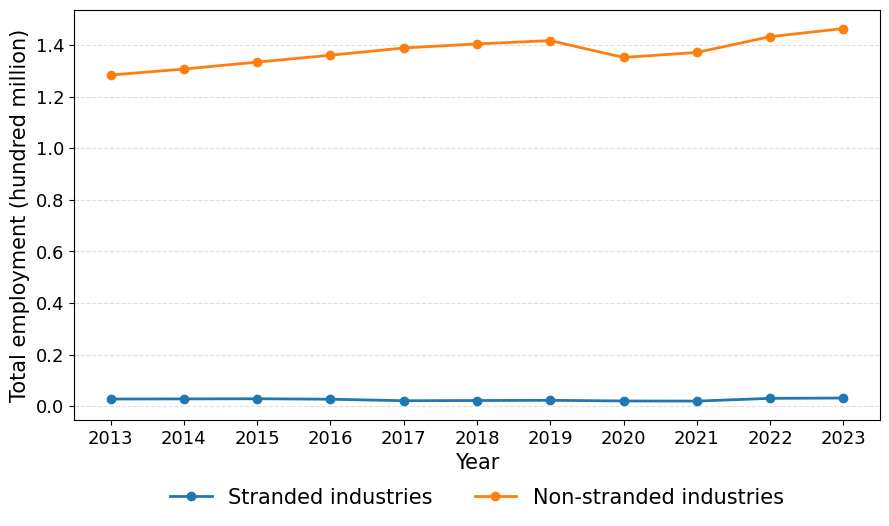

In [22]:
#Supplementary Figure 5B picture drawing
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# File Paths
# =========================
file_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/detailed_tot_emp_stranded_vs_non_stranded_2010_2023.csv")
out_png = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 5B.png")
out_svg = Path("Your path/Stranded_Occupations_Replication/Data/temp/Supplementary Figure 5B.svg")

# Load and clean data
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["stranded"] = pd.to_numeric(df["stranded"], errors="coerce")
df["non_stranded"] = pd.to_numeric(df["non_stranded"], errors="coerce")

# Filter for 2013-2023
plot_df = df[(df["year"] >= 2013) & (df["year"] <= 2023)].copy()
plot_df = plot_df.sort_values("year")

# Create plot
plt.figure(figsize=(9, 5.5), facecolor="white")

plt.plot(plot_df["year"], plot_df["stranded"], marker="o", linewidth=2, label="Stranded industries")
plt.plot(plot_df["year"], plot_df["non_stranded"], marker="o", linewidth=2, label="Non-stranded industries")

# Legend at bottom, two columns
plt.legend(
    frameon=False,
    fontsize=15,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Total employment (hundred million)", fontsize=15)
plt.title("", fontsize=13)
plt.xticks(plot_df["year"], rotation=0, fontsize=13)
plt.yticks(fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.gca().yaxis.get_offset_text().set_visible(False)

# Save figures
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()
